<a href="https://colab.research.google.com/github/princesapkota/worksheet01/blob/main/worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

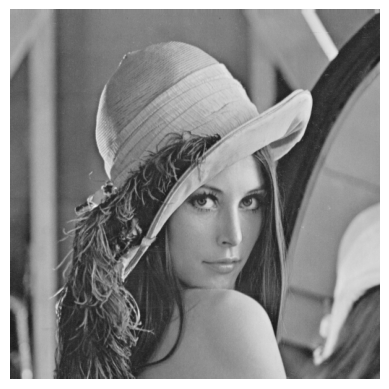

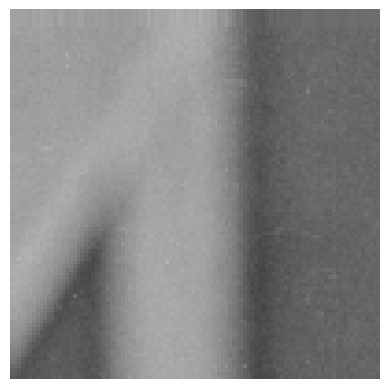

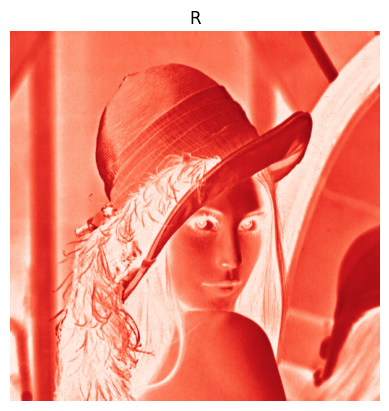

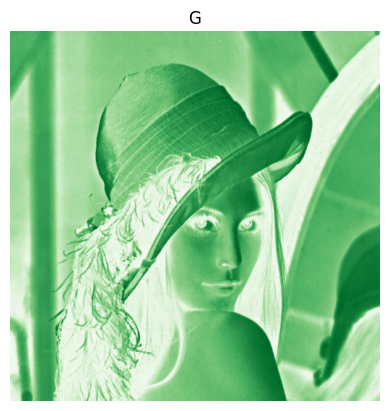

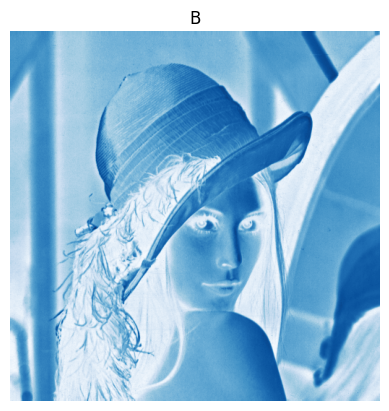

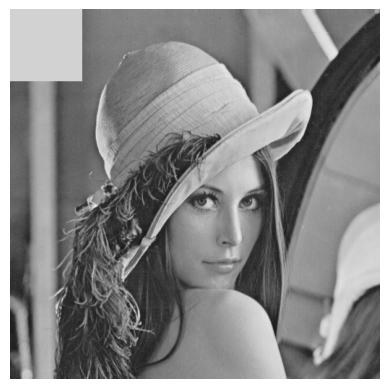

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# read image and force RGB
img = Image.open("/content/drive/MyDrive/AI ML/Data/lena_gray.gif").convert("RGB")
img_np = np.array(img)

# 1 display image
plt.imshow(img_np)
plt.axis("off")
plt.show()

# 2 top-left 100x100
corner = img_np[0:100, 0:100]
plt.imshow(corner)
plt.axis("off")
plt.show()

# 3 RGB channels
R = img_np[:, :, 0]
G = img_np[:, :, 1]
B = img_np[:, :, 2]

plt.imshow(R, cmap="Reds")
plt.title("R")
plt.axis("off")
plt.show()

plt.imshow(G, cmap="Greens")
plt.title("G")
plt.axis("off")
plt.show()

plt.imshow(B, cmap="Blues")
plt.title("B")
plt.axis("off")
plt.show()

# 4 modify top-left pixels
modified = img_np.copy()
modified[0:100, 0:100] = 210

plt.imshow(modified)
plt.axis("off")
plt.show()

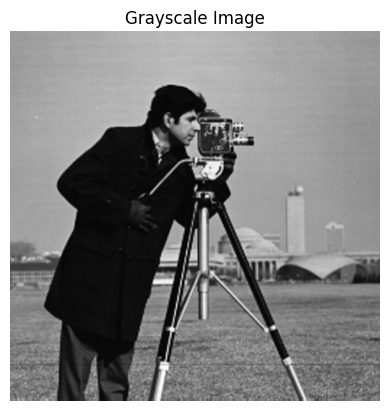

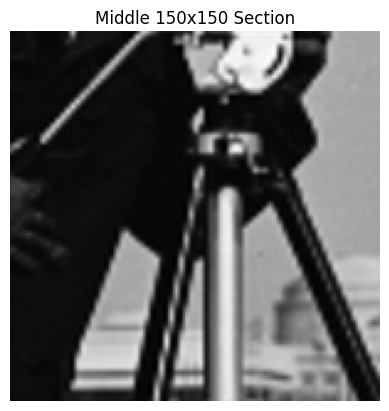

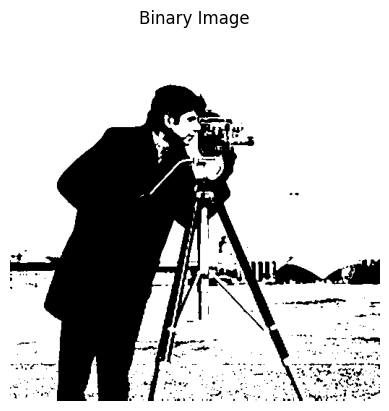

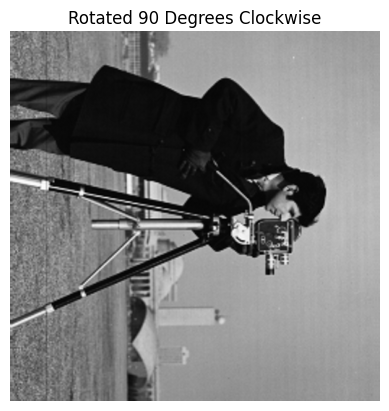

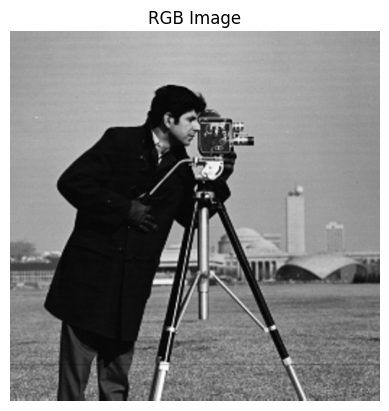

In [4]:

# load grayscale image
img = Image.open("/content/drive/MyDrive/AI ML/Data/cameraman.png").convert("L")
img_np = np.array(img)

# 1 display grayscale image
plt.imshow(img_np, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# 2 extract middle 150x150 section
h, w = img_np.shape
start_y = (h - 150) // 2
start_x = (w - 150) // 2
middle = img_np[start_y:start_y+150, start_x:start_x+150]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

# 3 apply threshold
binary = np.where(img_np < 100, 0, 255).astype(np.uint8)

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

# 4 rotate 90 degrees clockwise
rotated = img.rotate(-90, expand=True)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

# 5 convert grayscale to RGB
rgb_img = np.stack((img_np, img_np, img_np), axis=-1)

plt.imshow(rgb_img)
plt.title("RGB Image")
plt.axis("off")
plt.show()

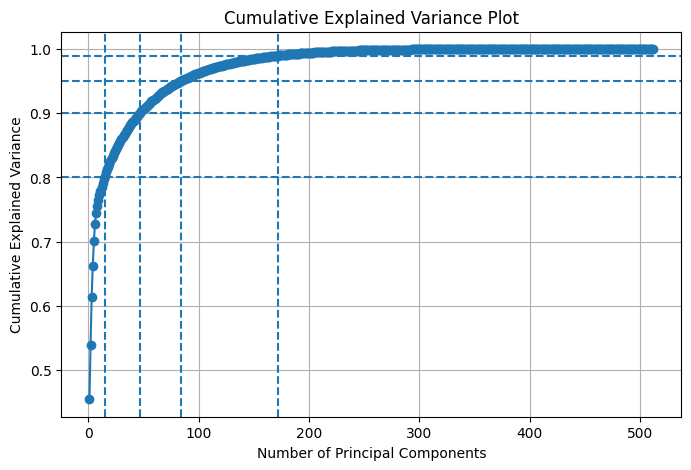

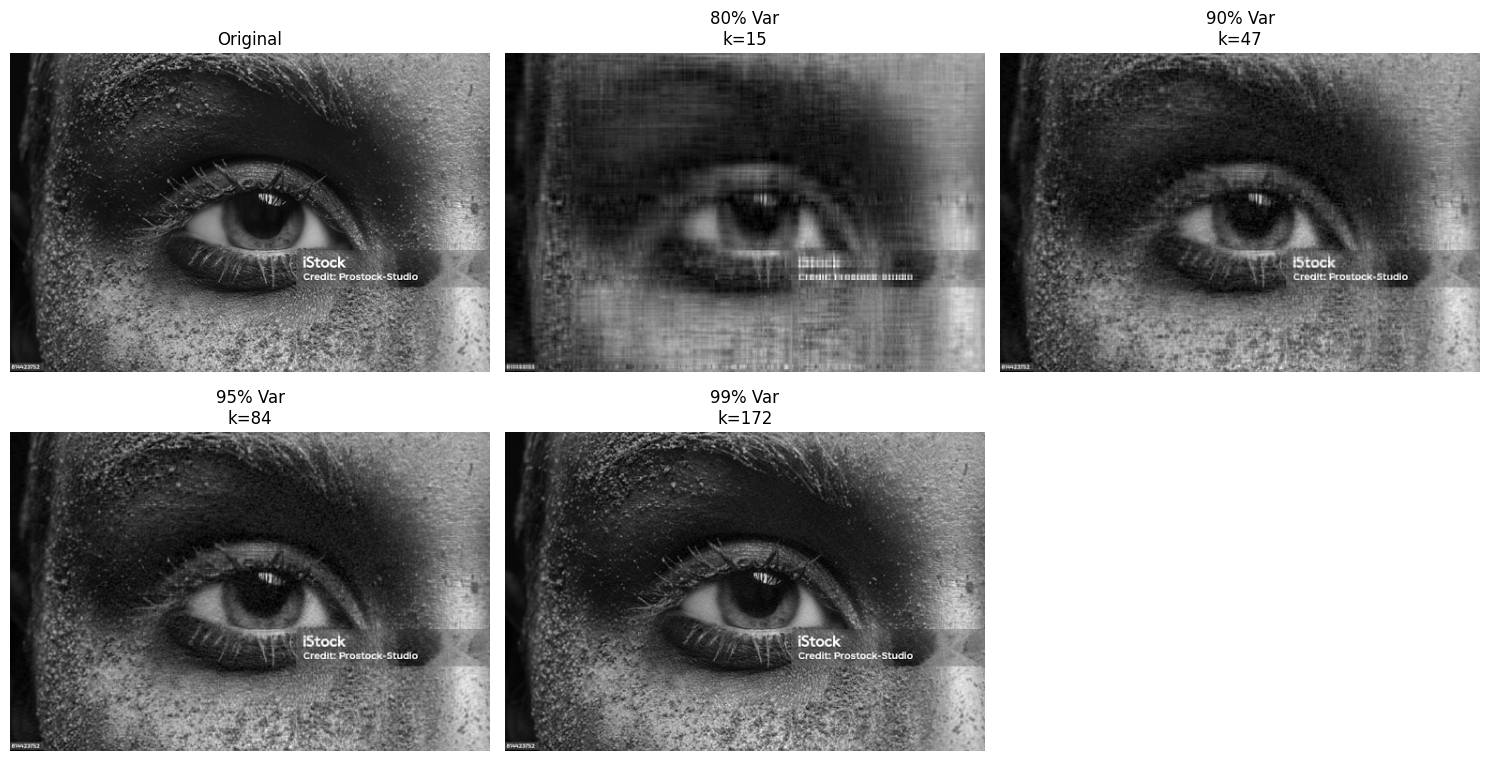

Principal components selected:
Explained Variance = 80% -> k = 15
Explained Variance = 90% -> k = 47
Explained Variance = 95% -> k = 84
Explained Variance = 99% -> k = 172

Reconstruction MSE:
80% variance: MSE = 310.9263
90% variance: MSE = 164.5776
95% variance: MSE = 86.8862
99% variance: MSE = 18.4763


In [5]:

# load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/AI ML/Data/eye.png").convert("L")
X = np.array(img, dtype=np.float64)

# standardize
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
std[std == 0] = 1
X_std = (X - mean) / std

# covariance matrix
cov_matrix = np.cov(X_std, rowvar=False)

# eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# explained variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# choose 4 variance levels
variance_levels = [0.80, 0.90, 0.95, 0.99]
k_values = [np.argmax(cumulative_variance >= v) + 1 for v in variance_levels]

# plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
for v, k in zip(variance_levels, k_values):
    plt.axhline(y=v, linestyle="--")
    plt.axvline(x=k, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()

# reconstruction function
def reconstruct(X_std, mean, std, eigenvectors, k):
    W = eigenvectors[:, :k]
    Z = X_std @ W
    X_recon_std = Z @ W.T
    X_recon = (X_recon_std * std) + mean
    X_recon = np.clip(X_recon, 0, 255)
    return X_recon.astype(np.uint8)

# reconstruct images
reconstructed_images = [reconstruct(X_std, mean, std, eigenvectors, k) for k in k_values]

# display results
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(X.astype(np.uint8), cmap="gray")
plt.title("Original")
plt.axis("off")

for i, (img_recon, k, v) in enumerate(zip(reconstructed_images, k_values, variance_levels), start=2):
    plt.subplot(2, 3, i)
    plt.imshow(img_recon, cmap="gray")
    plt.title(f"{int(v*100)}% Var\nk={k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# evaluation
print("Principal components selected:")
for v, k in zip(variance_levels, k_values):
    print(f"Explained Variance = {int(v*100)}% -> k = {k}")

print("\nReconstruction MSE:")
for v, img_recon in zip(variance_levels, reconstructed_images):
    mse = np.mean((X - img_recon) ** 2)
    print(f"{int(v*100)}% variance: MSE = {mse:.4f}")